<a href="https://colab.research.google.com/github/haxmxah/fermi_numerical_simulation/blob/main/fermi_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Master in Quantum Science and Technology**

Advanced Quantum Mechanics Class (2025-2026)




# **On the Quantization of the Monoatomic Ideal Gas** [reference]
In 1926, Enrico Fermi introduced a new way to describe an ideal gas by combining Bohr–Sommerfeld quantization with the Pauli exclusion principle. This work gave birth to Fermi–Dirac statistics, which explain the behavior of indistinguishable particles. The paper lied the correct statistical laws for fermions, forming the basis for modern condensed matter physics, astrophysics, and our understanding of quantum matter.



# Libraries

In [ ]:
import numpy as np
import seaborn as sns
from collections import defaultdict

from scipy.optimize import brentq
from scipy.integrate import quad

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from tqdm import tqdm

In [ ]:
sns.set_theme(
    context="notebook",
    font="Times New Roman",
    rc={
        "axes.labelweight": "bold",
        "axes.labelsize": 20,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "axes.titlesize": 22
    }
)
sns.set_style("whitegrid")
sns.set_style("ticks")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 0. Brief description of the mathematical development



Fermi considered particles confined by a spherical harmonic potential with restoring force defined as

$$
F = 4\pi^2 \nu^2 m r
$$

This was done in order to invoke the Bohr–Sommerfeld quantization and define the monoparticular energy as:

$$
E = h \nu (s_1 + s_2 + s_3), \quad s_1, s_2, s_3 \in \mathbb{Z} {\geq 0}.
$$


(*Note: In modern notation one usually writes $n$ instead of $s$, and adds the zero-point energy $3/2$.*)

Considering a total energy of

$$
W = h \nu \sum_s N_s
$$  

where $N_s$ (with $\sum_s N_s = N$) is the number of particles occupying the energy level $s$. Since each level $s$ has $Q_s$ possible quantum states, the occupation must satisfy  

$$
N_s \leq Q_s.
$$  

Optimizing the number of possible configurations for a given $Q_s$ and $N_s$.

$$
P = \prod_s \frac{Q_s!}{N_s!\,(Q_s - N_s)!}.
$$

Fermi can determine the density of particles (per unit volume) with a certain kinetic energy between $L$ and $dL$ and obtain:

* The density of states and occupation probability:

$$
N(L)dL = \frac{2 \pi (2 m)^{3/2}}{h^3} \sqrt{L}dL \frac{ A e^{-L/kT}}{1 + A e^{-L/kT}}
$$

* The total number of particles:

$$
n = \int_0^\infty n(L)\, dL
   = \frac{(2 \pi m k T)^{3/2}}{h^3} F(A).
$$

* The mean kinetic energy:

$$
\bar{L} = \frac{1}{n} \int_0^\infty L \, n(L)\, dL
= \tfrac{3}{2} kT \, \frac{G(A)}{F(A)}.
$$  

where  

$$
G(A) = \frac{4}{3\sqrt{\pi}} \int_0^\infty
\frac{A\, x^{3/2} e^{-x}}{1 + A e^{-x}} \, dx, \quad
F(A) = \frac{2}{\sqrt{\pi}} \int_0^\infty
\frac{A \, \sqrt{x} \, e^{-x}}{1 + A e^{-x}} \, dx, \quad
A = \alpha \, \exp\!\left(-\frac{2 \pi^2 \nu^2 m r^2}{kT}\right).
$$  


# 1. Numerical Resolution of the equations

For a given particle density, the parameter $A$ (related to the chemical potential) can be determined by solving:

$$
n = \frac{(2 \pi m k T)^{3/2}}{h^3} F(A),
$$

where $F(A)$ is a Fermi–Dirac type integral. Once $A$ is known, the mean energy per particle and the heat capacity can be computed.

At low temperatures ($T \to 0$), $A \to \infty$, which can cause numerical overflow and instability. To avoid this, we introduce a logarithmic variable $\eta = \ln(A)$ and the integrals become:

$$
F(\eta) = \frac{2}{\sqrt{\pi}} \int_0^\infty \frac{x^{1/2}}{e^{x-\eta} + 1} \, dx, \quad
G(\eta) = \frac{4}{3\sqrt{\pi}} \int_0^\infty \frac{x^{3/2}}{e^{x-\eta} + 1} \, dx.
$$

And the mean energy is then computed as:

$$
\langle E \rangle = \frac{3}{2} k_B T \frac{G(\eta)}{F(\eta)}.
$$

This ensures numerical stability when approaching to $T \rightarrow 0$ (logarithmically smaller rather than exponentially),Then we can compute the heat capacity:

$$
c_v = \frac{d \langle E \rangle}{d T}.
$$


In [ ]:
h = 1.0  # Planck Constant
k = 1.0  # Boltzmann Constant
m = 1.0  # Mass
n = 1.0  # Desity (particles/volume)

def F_fun(eta):
  f = lambda x : x**0.5 / (np.exp(x - eta) + 1)
  return (2/(np.pi)**0.5)*quad(f, 0, np.inf, epsabs=1e-12, epsrel=1e-12)[0]

def G_fun(eta):
  g = lambda x : x**(3/2) / (np.exp(x - eta) + 1)
  return 4/(3*np.pi**0.5)*quad(g, 0, np.inf, epsabs=1e-12, epsrel=1e-12)[0]


def eta_fun(T, n=n, h=h, m=m, k=k):
  RHS = (n * h**3) / ((2 * np.pi * m * k * T)**(3/2))
  f = lambda x: F_fun(x) - RHS

  try:
    eta_sol = brentq(f, -5, 500)
    return eta_sol

  except ValueError as e:
    print(f"We could not find a solution for A at T={T}. Error: {e}")
    return np.nan

def occupation_number(E, T):
  eta = eta_fun(T)
  mu = k * T * eta
  return 1.0 / (np.exp((E - mu) / (k * T)) + 1.0), mu


def mean_system_energy(T):
  eta = eta_fun(T)
  return (3/2)*T*G_fun(eta)/(F_fun(eta))

In [ ]:
steps = 1000
Tn = np.linspace(1e-3, 1.5, steps)

mEn = np.zeros(steps)
dEn = np.zeros(steps)

mEn = [ mean_system_energy(t) for t in Tn ]
dEn = np.gradient(mEn, Tn)

/tmp/ipython-input-2647161212.py:7: RuntimeWarning: overflow encountered in exp
  f = lambda x : x**0.5 / (np.exp(x - eta) + 1)
/tmp/ipython-input-2647161212.py:11: RuntimeWarning: overflow encountered in exp
  g = lambda x : x**(3/2) / (np.exp(x - eta) + 1)


## Occupation number

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1030729967.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$E/\mu$")
/tmp/ipython-input-2647161212.py:7: RuntimeWarning: overflow encountered in exp
  f = lambda x : x**0.5 / (np.exp(x - eta) + 1)


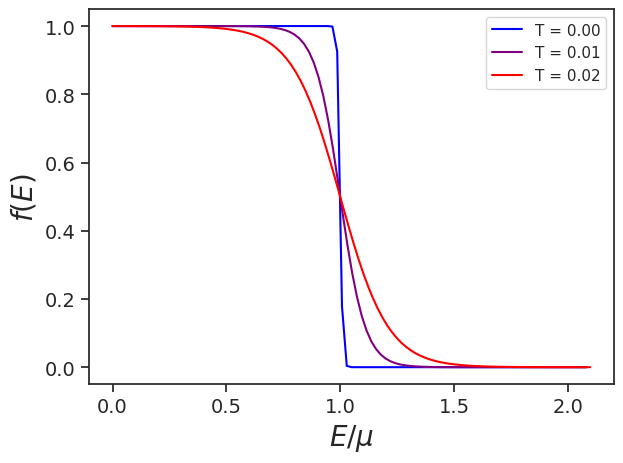

In [ ]:
E_values = np.linspace(0, 0.4, 100)
T_values = np.linspace(1e-3, 2e-2, 3)

plt.figure()

cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])
colors = cmap(np.linspace(0, 1, len(T_values)))

for t,c in zip(T_values, colors):
  fE, mu = occupation_number(E_values, t)
  plt.plot(E_values/mu, fE, label=f"T = {t:.2f}", color=c)

plt.legend()
plt.xlabel("$E/\mu$")
plt.ylabel("$f(E)$")
plt.tight_layout()
plt.show()


## Mean Energy of the System

We can verify the expected behavior of the mean energy in different temperature regimes:

* As $T \to 0$, the system is in the quantum degenerate regime, and $\langle E \rangle \propto T^2$, showing a non-linear dependence on temperature.

* As $T$ increases and the system approaches the classical limit$
  \langle E \rangle \propto \frac{3}{2}T$, consistent with the equipartition theorem for a classical ideal gas.


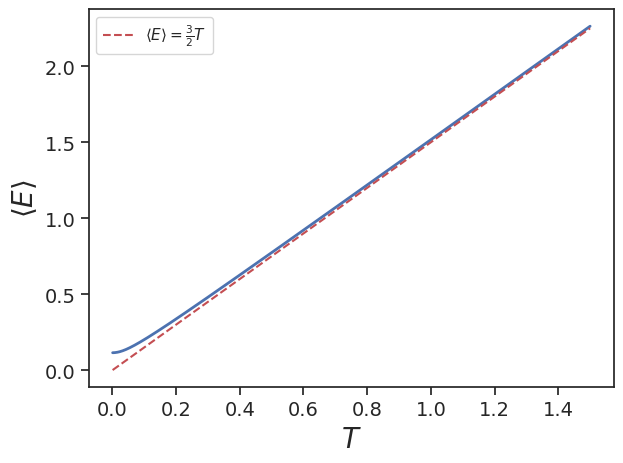

In [ ]:
T_high = np.linspace(min(Tn), max(Tn), 100)

fig, ax = plt.subplots()

sns.lineplot(x=Tn, y=mEn, ax=ax, linewidth=2, color='C0')
ax.plot(T_high, 1.5 * T_high, 'r--', label=r"$\langle E \rangle = \frac{3}{2}T$")
ax.legend()

ax.set_xlabel("$T$")
ax.set_ylabel(r"$\langle E \rangle$")
plt.tight_layout()
plt.show()

## Heat Capacity
We can verify the expected behavior of the heat capacity in different temperature regimes:

* As $T \to 0$, the system is in the quantum degenerate regime, and $c_v = \frac{d \langle E \rangle}{dT} \propto T $, showing a linear, non-classical dependence on temperature.

* As $T$ increases and the system approaches the classical limit, $c_v \to \frac{3}{2} k_B $ consistent with the classical equipartition theorem for a 3D ideal gas.


In [ ]:
def cv_paper(T):
    return (16*np.pi**8/9)**(1/3)*(m*k**2)/(h**2*n**(2/3))*T

cv_low_T = cv_paper(Tn)

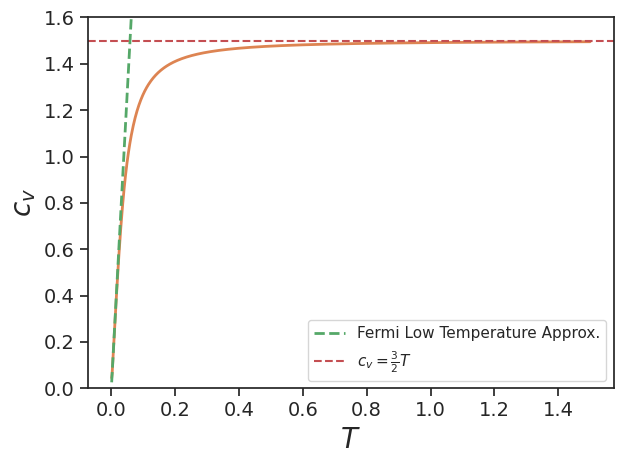

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(x=Tn, y=dEn, ax=ax, linewidth=2, color='C1')
sns.lineplot(x=Tn, y=cv_low_T, ax=ax, linewidth=2, color='C2', linestyle='--', label='Fermi Low Temperature Approx.')

ax.axhline(y=1.5, color='r', linestyle='--', label=r"$c_v = \frac{3}{2} T$")

ax.set_ylim(0, 1.6)
ax.set_xlabel("$T$")
ax.set_ylabel(r"$c_v$")
ax.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Ideal Quantum Gas Simulation of 1000 particles

This code is an implementation of the algorithm proposed by Clark University [1], but instead, we considered particles confined in a spherical harmonic potential, just like Fermi did.

$$
E = h \nu (n_x + n_y + n_z + \frac{3}{2})
$$

[1] Clark University. *Quantum Monte Carlo simulations*. https://stp.clarku.edu/simulations/qmc/index.html




In [ ]:

def fermi_dirac_statistics(E, mu, T):
  """
  Compute the Fermi-Dirac distribution for a given energy level.

  Arguments:
  * E(float): Energy level(s) at which to evaluate the distribution.
  * mu(float): Chemical potential of the system (a.k.a mu).
  * T(float):Temperature (in the same energy units as E and mu).

  Returns:
  * f(E)(float): Occupation probability of the state.
  """
  return 1 / (1 + np.exp((E - mu) / T))

def mu_value(energies, N, T):
  """
  Computes the Fermi energy (chemical potential) for a system of fermions.

  Arguments:
  * energies(array): Array of energy levels of the system.
  * N(int): Number of particles.
  * T(float): Temperature (in the same units as energies).

  Returns:
  * mu(float): Chemical potential that satisfies the particle number constraint.
  """
  def equation(mu):
    return np.sum(fermi_dirac_statistics(energies, mu, T)) - N

  return brentq(equation, np.min(energies)-1000, np.max(energies)+1000)

def get_energy_states(g_n, N, n):
  """
  Generates the 3D harmonic oscillator energy states for a given number
  of particles.

  Arguments:
  * g_n(int): Initial degeneracy counter.
  * N(int): Number of particles.
  * n(int): Initial quantum number.

  Returns:
  * states(list of tuples): List of allowed quantum states (nx, ny, nz)
    satisfying nx + ny + nz <= n & extra levels for excitations.
  """
  while g_n <= N:
    g_n += int((n+1)*(n+2)/2)
    n += 1

  # Extra energy levels for excited states
  n += 25
  # 20

  # Harmonic energy
  states = [
      (nx, ny, nz)
      for nx in range(0, n+1)
      for ny in range(0, n+1)
      for nz in range(0, n+1)
      if nx + ny + nz <= n
  ]

  return states

def fermion_ideal_gas_simulation(N, T, mcs_steps, energies):
  """
  Simulates the occupation of energy states in an ideal Fermi gas using
  Monte Carlo steps and the Metropolis algorithm.

  Arguments:
  * N(int): Number of fermions.
  * T(float): Temperature (in the same units as energies).
  * mcs_steps(int): Number of Monte Carlo steps to perform.
  * energies(array): Array of energy levels of the system.

  Returns:
  * occupation(array): Average occupation probability of each energy state.
  """
  n_states = len(energies)

  occupied_states = np.zeros(n_states, dtype=int)
  occupied_states[:N] = 1

  occupation_sum = np.zeros(n_states)
  total_energy_sum = 0

  current_E_total = np.sum(occupied_states * energies)
  skip_mcs_steps = 0.1*mcs_steps
  # rng = np.random.default_rng(1)
  # random = rng.random(300_000)
  for step in range(mcs_steps):
    occupied_idx = np.where(occupied_states == 1)[0]
    empty_idx = np.where(occupied_states == 0)[0]

    k_occupied_idx = np.random.choice(occupied_idx)
    k_empty_idx = np.random.choice(empty_idx)

    dE = energies[k_empty_idx] - energies[k_occupied_idx]

    # Metropolis method for acceptance and rejection
    #np.random.rand()

    if dE < 0 or ( np.random.rand() < np.exp(-dE / T) ):
      # Exchange particle
      occupied_states[k_occupied_idx] = 0
      occupied_states[k_empty_idx] = 1
      current_E_total += dE

    if step > skip_mcs_steps:
      occupation_sum += occupied_states
      total_energy_sum += current_E_total


  mean_occupation = occupation_sum / (mcs_steps-skip_mcs_steps)
  mean_total_energy_per_particle = (total_energy_sum / (mcs_steps-skip_mcs_steps)) / N


  return mean_occupation, mean_total_energy_per_particle

def mc_simulation(N, temperatures):
  n = 0    # Energy Quantum Number nx + ny + nz = n
  g_n = 0  # Available number of states given an n

  # Available energies for the system
  states = get_energy_states(g_n, N, n)         # Energy states
  energies = np.array([sum(n) for n in states])
  energies = np.sort(energies)
  n_states = len(states)

  # To save the energy
  occupation_list = []
  mean_energy_T = []

  # Montecarlo Method
  mcs_steps = 500_000
  n_iterations = 5

  plt.figure()
  cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])
  colors = cmap(np.linspace(0, 1, len(temperatures)))

  for T, color in tqdm(zip(temperatures, colors), total=len(temperatures), desc="Fermion Gas Simulation"):
    print("Temperature", T)
    mean_energy_iter = []
    mean_cv_iter = []

    for iteration in range(n_iterations):
      occupation, mean_energy_particle = fermion_ideal_gas_simulation(N, T, mcs_steps, energies)
      mean_energy_iter.append(mean_energy_particle)

    mean_energy_T.append(np.mean(mean_energy_iter))

    # Group occupation by energy due to degeneracy
    energy_occupation = {}
    for e, o in zip(energies, occupation):
      if e not in energy_occupation:
          energy_occupation[e] = []

      energy_occupation[e].append(o)

    E_vals = np.array(sorted(energy_occupation.keys()))
    occupation_vals = np.array([np.mean(energy_occupation[e]) for e in E_vals])

    # Fermi-Dirac Theoretical Distribution
    mu = mu_value(energies, N, T)
    theoretical_vals = [fermi_dirac_statistics(E, mu, T) for E in E_vals]

    # Save occupation for specific temperatures
    occupation_list.append({"temperature": T, "energy": E_vals, "occupation": occupation_vals, "mu": mu})

  return occupation_list, mean_energy_T, temperatures


## Occupation Number

Here we present the resulting occupation number for 5 different temperatures from the MC simulation along its theoretical values. The energy is normalized to the chemical potential, which is dependent on the temperature.

In [ ]:
N = 1000 # Number of particles
temperatures = np.linspace(1e-6, 2, 5)

occupation_list, mean_energy_T, temperatures = mc_simulation(N, temperatures)


Fermion Gas Simulation:   0%|          | 0/5 [00:00<?, ?it/s]

Temperature 1e-06


/tmp/ipython-input-2949202797.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp((E - mu) / T))
Fermion Gas Simulation:  20%|██        | 1/5 [02:51<11:24, 171.10s/it]

Temperature 0.50000075


Fermion Gas Simulation:  40%|████      | 2/5 [05:35<08:20, 166.97s/it]

...

Temperature 1.50000025


Fermion Gas Simulation:  80%|████████  | 4/5 [11:06<02:45, 165.65s/it]

Temperature 2.0


Fermion Gas Simulation: 100%|██████████| 5/5 [13:48<00:00, 165.70s/it]


<Figure size 640x480 with 0 Axes>

In [ ]:
# with open("/content/drive/MyDrive/data/occupation_list.npy", "wb") as f:
#   np.save(f, occupation_list)

# with open("/content/drive/MyDrive/data/mean_energy_T.npy", "wb") as f:
#   np.save(f, mean_energy_T)

# with open("data/temperatures.npy", "rb") as f:
#   np.save(f, temperatures)

# occupation_list = np.load("/content/drive/MyDrive/data/occupation_list.npy", allow_pickle=True)

/tmp/ipython-input-2949202797.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp((E - mu) / T))


16.639985440335415 0.50000075
16.503920139077227 1.0000005
16.277667755254512 1.50000025
15.961152950746348 2.0


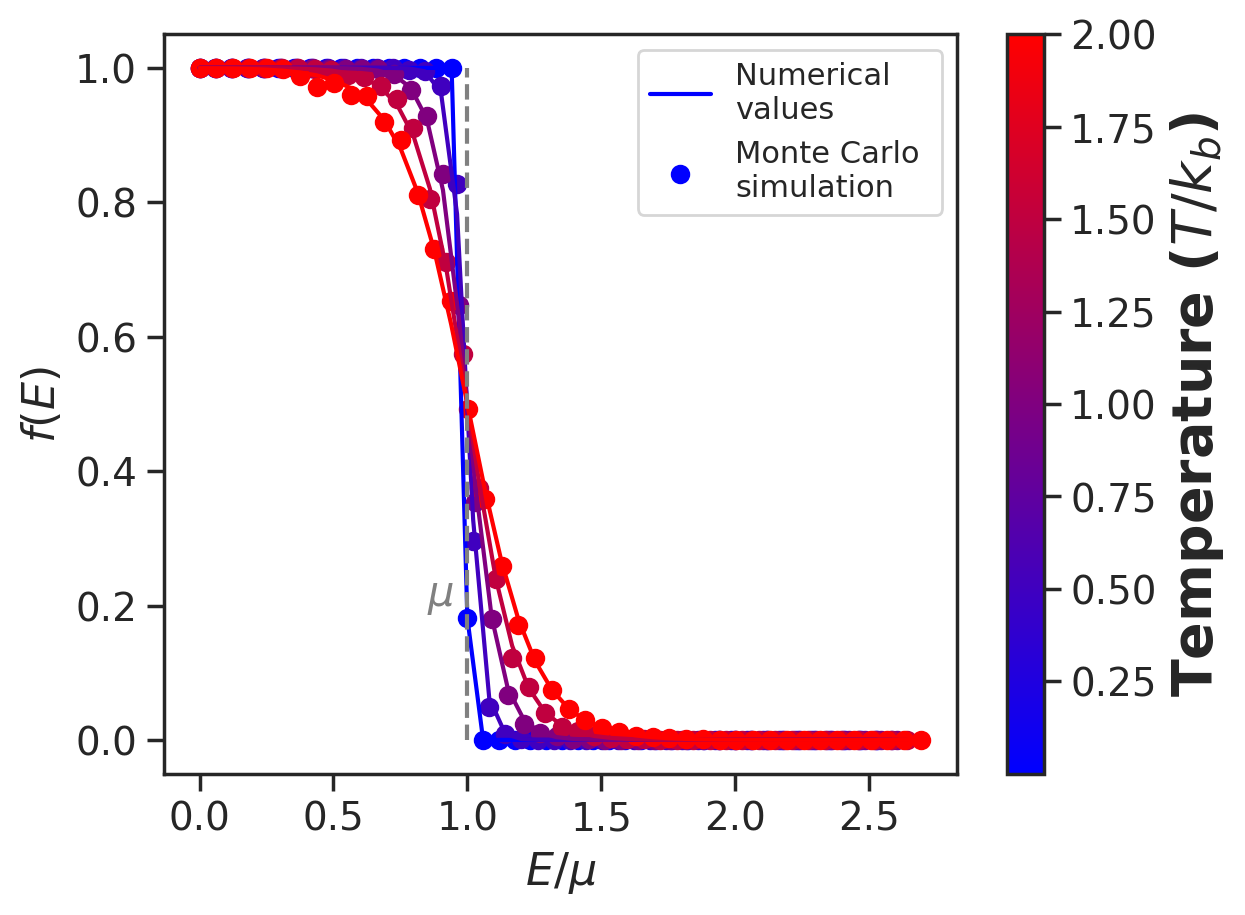

In [ ]:
import matplotlib as mpl

T_values = [occupation["temperature"] for occupation in occupation_list]
fig, ax = plt.subplots(dpi=200)
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])

# Custom colorbar
norm = mpl.colors.Normalize(vmin=min(T_values), vmax=max(T_values))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Temperature ($T/k_b$)")
colors = cmap(np.linspace(0, 1, len(T_values)))

# First iteration marks the legend
first_occupation = occupation_list[0]
T = first_occupation["temperature"]
E_vals = first_occupation["energy"]
mu = first_occupation["mu"]
theoretical_vals = [fermi_dirac_statistics(E, mu, T) for E in E_vals]
occupation_vals = first_occupation['occupation']

ax.plot(E_vals/mu, theoretical_vals, color=colors[0],
        label="Numerical\nvalues")

ax.scatter(E_vals/mu, occupation_vals, color=colors[0],
           label="Monte Carlo \nsimulation")

# We iterate the rest
for i in range(1, len(occupation_list)):
    current_occupation = occupation_list[i]
    T = current_occupation["temperature"]
    E_vals = current_occupation["energy"]
    mu = current_occupation["mu"]
    theoretical_vals = [fermi_dirac_statistics(E, mu, T) for E in E_vals]
    occupation_vals = current_occupation['occupation']
    print(mu, T)
    ax.plot(E_vals/mu, theoretical_vals, color=colors[i])
    ax.scatter(E_vals/mu, occupation_vals, color=colors[i])


ax.set_xlabel("$E/\\mu$", fontsize=16)
ax.set_ylabel("$f(E)$", fontsize=16)
ax.vlines(1, 0, 1, ls="--", color="gray")
ax.legend()
ax.text(0.85, 0.2,"$\\mu$", color="gray", fontsize=15)
fig.savefig("ocupation_numvssim.png", bbox_inches="tight")


## Energy as a function of T ($E(T)$)
The MC simulation is run for 40 different temperatures.

In [ ]:
N = 1000 # Number of particles
temperatures = np.linspace(1e-6, 5, 40)
occupation_list, mean_energy_T, temperatures = mc_simulation(N, temperatures)

Fermion Gas Simulation:   0%|          | 0/40 [00:00<?, ?it/s]

Temperature 1e-06


/tmp/ipython-input-2666872514.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp((E - mu) / T))
Fermion Gas Simulation:   2%|▎         | 1/40 [04:35<2:59:15, 275.79s/it]

Temperature 0.12820610256410256


Fermion Gas Simulation:   5%|▌         | 2/40 [09:03<2:51:41, 271.11s/it]

...

Temperature 4.8717948974358976


Fermion Gas Simulation:  98%|█████████▊| 39/40 [2:58:38<04:43, 283.80s/it]

Temperature 5.0


Fermion Gas Simulation: 100%|██████████| 40/40 [3:03:22<00:00, 275.06s/it]


<Figure size 640x480 with 0 Axes>

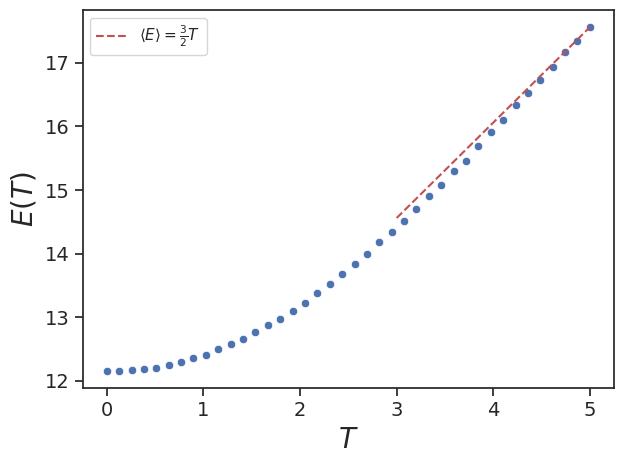

In [ ]:
plt.figure()

sns.scatterplot(x=temperatures, y = mean_energy_T)

T_high = np.linspace(3, 5, 5)
slope = 3/2
T_ref = 5
E_ref = np.interp(T_ref, temperatures, mean_energy_T)
b = E_ref - slope * T_ref
E_high= slope * T_high + b

sns.lineplot(x=T_high, y=E_high, color='r', linestyle='--', label=r'$\langle E \rangle = \frac{3}{2}T$')

plt.xlabel("$T$")
plt.ylabel("$E(T)$")
plt.legend()
plt.tight_layout()
# plt.savefig("plots/simulation_energy.pdf")

## Heat capacity as a function of T

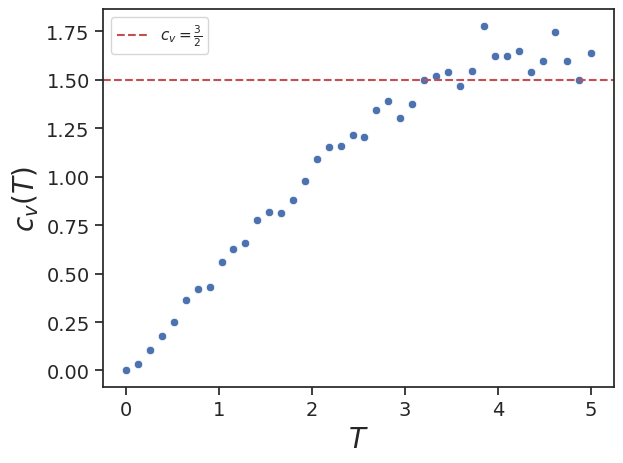

In [ ]:
plt.figure()

dEdT = np.gradient(mean_energy_T, temperatures)
sns.scatterplot(x=temperatures, y = dEdT)
plt.axhline(y=1.5, color='r', linestyle='--', label = r"$c_v = \frac{3}{2}$")

plt.xlabel("$T$")
plt.ylabel("$c_v(T)$")
plt.legend()
plt.tight_layout()
# plt.savefig("plots/simulation_cv.pdf")